# Example of the AiTLAS toolbox for generating feature embeddings using AnySat

## Define the FAIREOSchema for dataset import

In [1]:
from marshmallow import fields, validate
from aitlas.base.schemas import BaseDatasetSchema

class FAIREOSchema(BaseDatasetSchema):
    """
    Schema for configuring Cloud AI4QC datasets.
    """
    csv_file = fields.String(
        load_default=None, 
        metadata={
            "description": "CSV file on disk", 
            "example": "./data/train.csv"
        }
    )
    data_dir = fields.String(
        load_default="/", 
        metadata={
            "description": "Dataset path on disk", 
            "example": "./data/CESBIO/"
        }
    )
    selection = fields.String(
        load_default="rgb", 
        metadata={
            "description": "Read RGB channels or 13 channels", 
            "example": "all/rgb"
        }
    )

## Define the SEN12MSDataset class
This dataset contains both Sentinel-1 and Sentinel-2 images

In [2]:
import numpy as np
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from skimage.transform import resize
import torch
from matplotlib.patches import Patch
import csv
import math

from aitlas.datasets.semantic_segmentation import SemanticSegmentationDataset
from aitlas.utils import image_loader

"""
The SEN12MS dataset contains 180,662 patch triplets of corresponding Sentinel-1 dual-pol SAR data, 
Sentinel-2 multi-spectral images, and MODIS-derived land cover maps.
"""

class SEN12MSDataset(SemanticSegmentationDataset):
    url = "https://dataserv.ub.tum.de/s/m1474000"

    labels = ["no-data","Evergreen needleleaf forest","Evergreen broadleaf forest","Deciduous needleleaf forest",
              "Deciduous broadleaf forest","Mixed forest","Closed shrublands","Open shrublands","Woody savannas",
              "Savannas","Grasslands","Permanent wetlands","Croplands","Urban and built-up","Cropland/Natural vegetation mosaic",
              "Snow and ice","Barren or sparsely vegetated","Water"]
    color_mapping = [[255,255,255],[252,132,255],[253,0,1],[0,255,4],[2,0,255],[253,255,0],[1,255,255],[253,0,254],[123,2,1],[122,255,255],
                     [0,0,128],[255,255,126],[128,0,251],[253,128,0],[1,130,252],[126,255,0],[133,1,128],[128,254,128]] 
    name = "SEN12MS"
    schema = FAIREOSchema

    def __init__(self, config):
        # now call the constructor to validate the schema and split the data
        super().__init__(config)
        self.data_dir = self.config.data_dir
        self.selection = self.config.selection
        self.csv_file = self.config.csv_file

    def __getitem__(self, index):
        # Check whether the self.images has two channels (Sentinel-1) or more channels (Sentinel-2)
        temp_image = image_loader(self.images[index])
        if temp_image.shape[2] == 2:
            # Sentinel-1 has two channels (VV and VH)
            image = temp_image[:,:,0:2]/10000
        elif temp_image.shape[2] > 2:
            # Sentinel-2 has 13 channels, but we only use RGB here
            image = temp_image[:,:,1:4]/10000
        else:
            raise ValueError("The input image must have at least 2 channels (Sentinel-1) or more than 2 channels (Sentinel-2)")

        mask = image_loader(self.masks[index])[:,:,0]
        masks = [(mask == v) for v, label in enumerate(self.labels)]
        mask = np.stack(masks, axis=-1).astype("float32")

        return self.apply_transformations(image, mask)

    def load_dataset(self, data_dir, csv_file):
        if not self.labels:
            raise ValueError("You need to provide the list of labels for the dataset")

        # Get all files, then filter for valid TIFF images
        all_ids = os.listdir(data_dir)
        ids = [
            f for f in all_ids
            if f.lower().endswith(('.tif', '.tiff')) and not f.startswith('.')
        ]
        
        split_list = []
        ids_final = []
        if csv_file: 
            with open(csv_file, mode ='r') as file:
                csvFile = csv.reader(file)
                for lines in csvFile:
                    split_list.append(lines[0][3 :])
            for i in ids:
                if i in split_list:
                    ids_final.append(i)
            ids = ids_final

        # Path to images
        self.images = [os.path.join(data_dir, image_id) for image_id in ids]
        # Find the parent directory of data_dir (e.g., go from .../images to .../)
        images_dir = os.path.abspath(os.path.join(data_dir, ".."))
        parent_dir = os.path.abspath(os.path.join(images_dir, ".."))
        # Construct the correct path to the labels directory
        labels_dir = os.path.join(parent_dir, "labels")
        # Path to masks/labels
        self.masks = [
            os.path.join(labels_dir, image_id.replace('_s1_', '_lc_').replace('_s2_', '_lc_'))
            for image_id in ids
        ]
    
    def data_distribution_table(self):
        label_dist = {key: 0 for key in self.labels}
        for image, mask in self.dataloader():
            for index, label in enumerate(self.labels):
                label_dist[self.labels[index]] += mask[:, :, :, index].sum()
        label_count = pd.DataFrame.from_dict(label_dist, orient='index')
        label_count.columns = ["Number of pixels"]
        label_count = label_count.astype(float)
        return label_count
    
    def data_distribution_barchart(self, show_title=True):
        label_count = self.data_distribution_table()
        fig, ax = plt.subplots(figsize=(12, 12))
        sns.barplot(data=label_count, x=label_count.index, y='Number of pixels', ax=ax)
        fig.autofmt_xdate()
        if show_title:
            ax.set_title(
                "Labels distribution for {}".format(self.get_name()), pad=20, fontsize=18
            )
        return fig

    def show_image(self, index, show_title=False):
        img, mask = self[index]
        img_mask = np.zeros([mask.shape[0], mask.shape[1], 3], np.uint8)
        
        # Check if the image is Sentinel-1 (2 channels) or Sentinel-2 (3 or more channels)
        is_sentinel1 = (img.ndim == 3 and img.shape[2] == 2)
        
        legend_elements = []
        for i, label in enumerate(self.labels):
            legend_elements.append(
                Patch(
                    facecolor=tuple([x / 255 for x in self.color_mapping[i]]),
                    label=self.labels[i],
                )
            )
            img_mask[np.where(mask[:, :, i] == 1)] = self.color_mapping[i]

        # Adjust plot layout based on image type
        if is_sentinel1:
            fig, axes = plt.subplots(1, 3, figsize=(15, 5)) # 1 row, 3 columns
            # Plot Channel 1 (e.g., VV)
            axes[0].imshow(img[:, :, 0], cmap='gray')
            axes[0].set_title("S1 Channel 1 (VV)")
            axes[0].axis("off")  
            # Plot Channel 2 (e.g., VH)
            axes[1].imshow(img[:, :, 1], cmap='gray')
            axes[1].set_title("S1 Channel 2 (VH)")
            axes[1].axis("off")   
            # Plot the mask
            axes[2].imshow(img_mask)
            axes[2].set_title("Mask")
            axes[2].axis("off")
        else: # For Sentinel-2 or other standard RGB images
            fig, axes = plt.subplots(1, 2, figsize=(10, 5)) # 1 row, 2 columns
            axes[0].imshow(img)
            axes[0].set_title("Image")
            axes[0].axis("off")
            axes[1].imshow(img_mask)
            axes[1].set_title("Mask")
            axes[1].axis("off")

        fig.legend(handles=legend_elements, bbox_to_anchor=(0.1, 0, 0.8, 0.15), ncol=3, mode='expand',
                loc='lower center', prop={'size': 10})
        fig.tight_layout(rect=[0, 0.15, 1, 0.95])
        
        if show_title:
            fig.suptitle(f"Image and Mask for index {index}", fontsize=16)
            
        plt.show()
        return fig

/home/dragik/anaconda3/envs/aitlas-py312/lib/python3.12/site-packages/eolearn/__init__.py:13: UserWarning: You are currently using an outdated installation of `eo-learn` for submodules ['core', 'geometry']. You can find instructions on how to install `eo-learn` correctly at https://github.com/sentinel-hub/eo-learn/issues/733.
  warnings.warn(
/home/dragik/anaconda3/envs/aitlas-py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Prepare the model

In [3]:
from aitlas.models import AnySat

model_config = {
        "local_model_path": "tests/checkpoints/AnySat.pth",
        "backbone_name": "anysat_base",
        "pretrained": True,
        "flash_attn": True # Flash attention reduces runtime significantly
    }

model = AnySat(model_config)

print(model_config["local_model_path"])

Loading weights from the provided local path: tests/checkpoints/AnySat.pth
Successfully loaded checkpoint: AnySat.pth
tests/checkpoints/AnySat.pth


## Examples

### 1. Sentinel-1 examples

Load an example dataset with Sentinel-1 images

In [4]:
dataset_s1_config = {
    "data_dir": "/home/dragik/data/FAIR_EO/SEN12MS/images/s1",
    "csv_file": "/home/dragik/data/FAIR_EO/SEN12MS/test.csv",
}
dataset_s1 = SEN12MSDataset(dataset_s1_config)

print(f"Total number of patches: {len(dataset_s1)}")

Total number of patches: 17918


Plot images and show data distribution

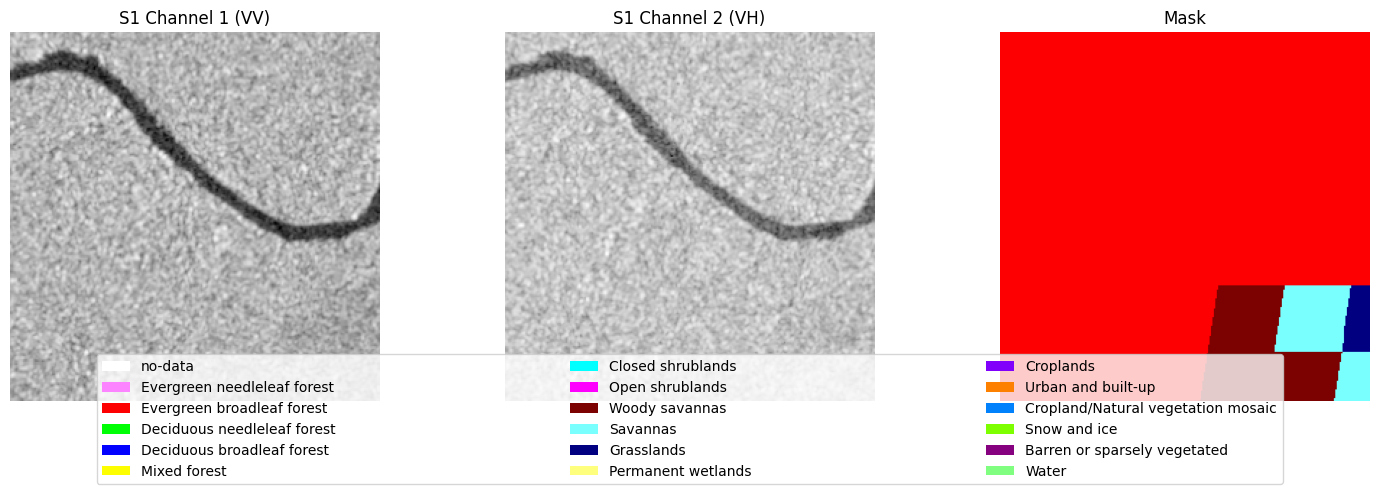

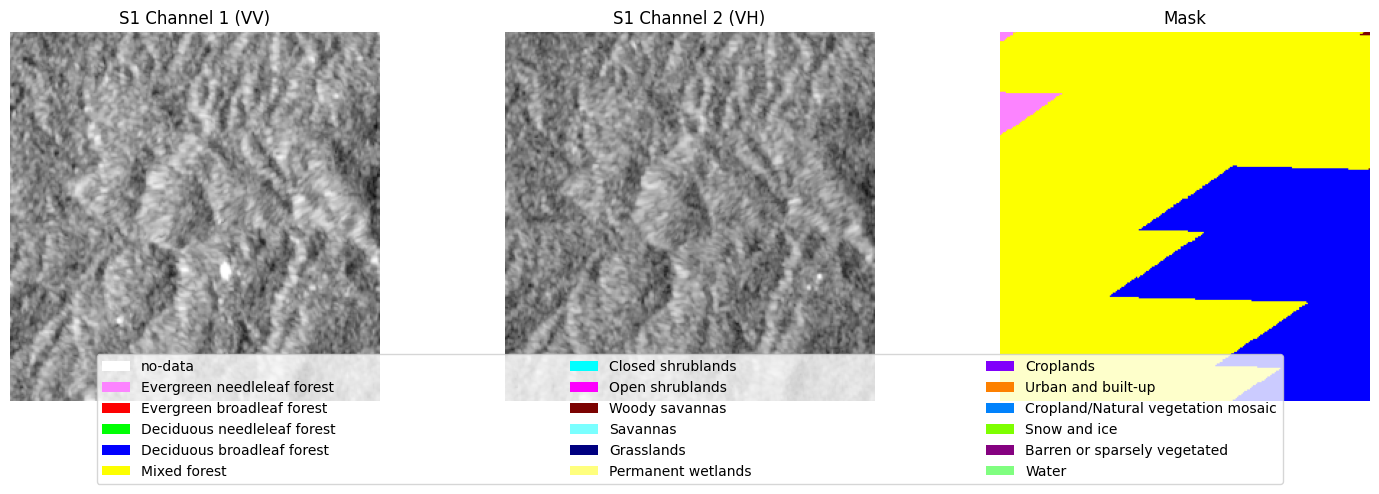

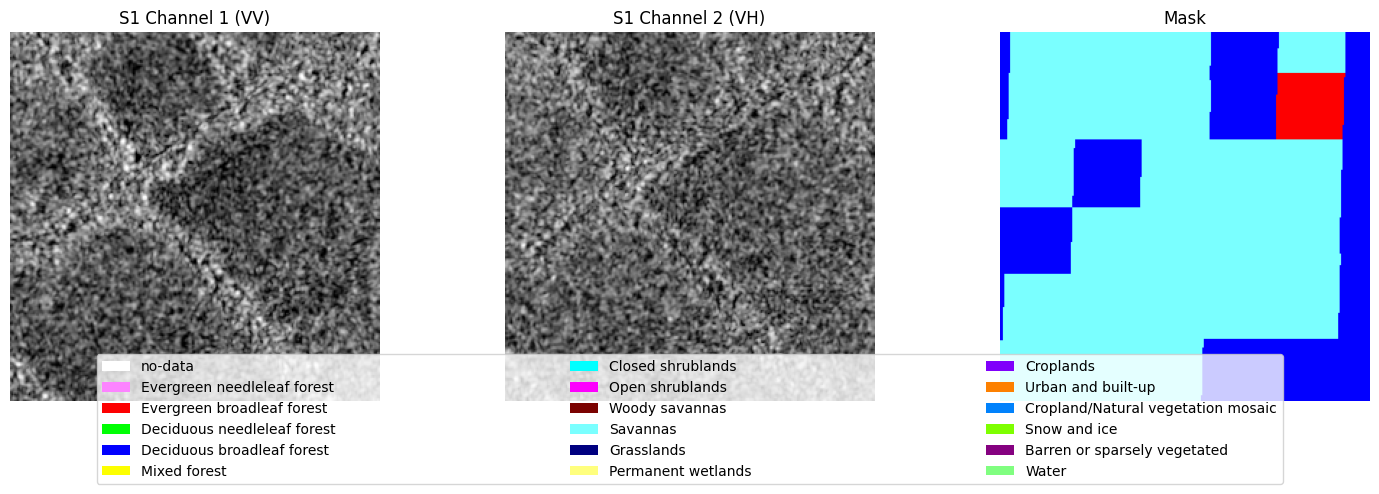

In [5]:
dataset_s1.show_image(1);
dataset_s1.show_image(50);
dataset_s1.show_image(999);

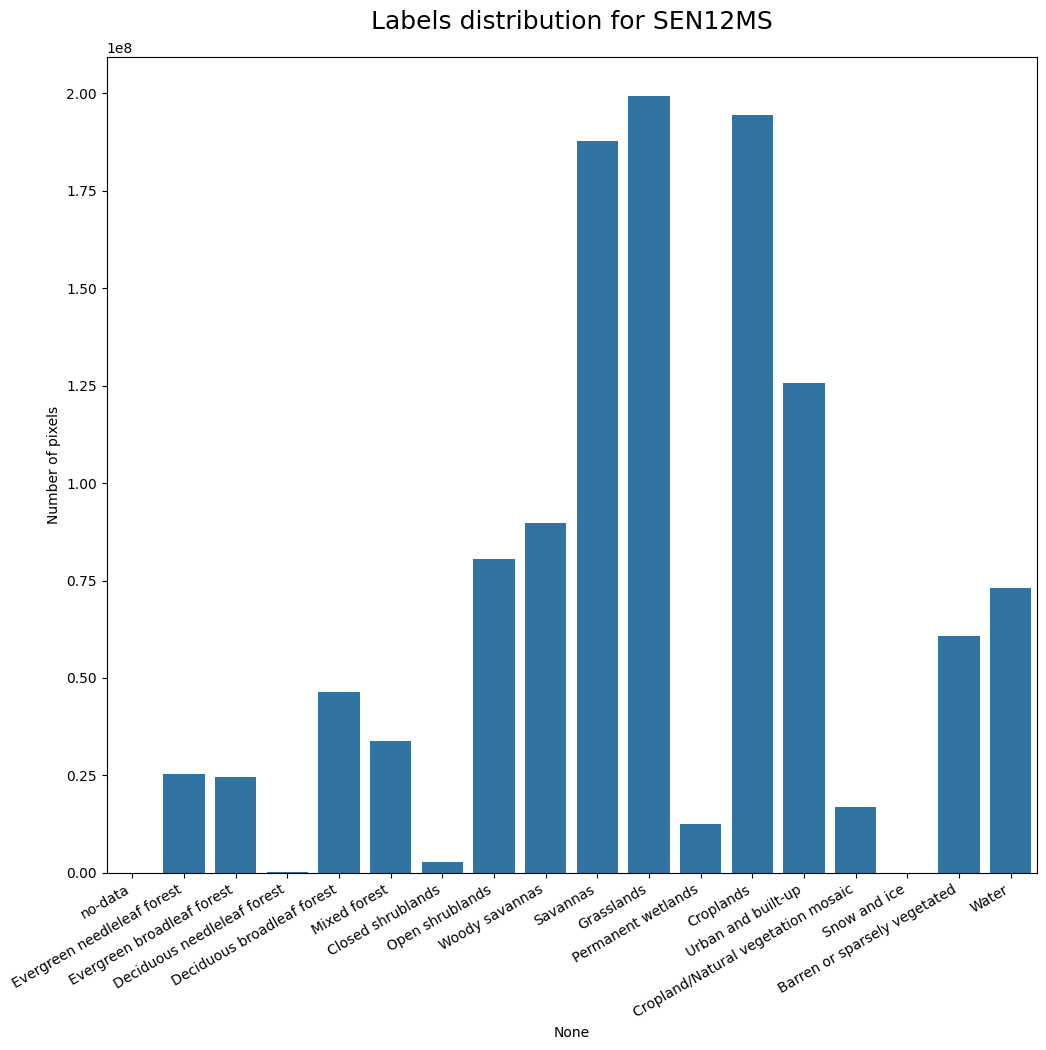

In [6]:
dataset_s1.data_distribution_barchart();

#### 1.1 Example: Get feature embeddings for Sentinel-1 images as input

Load, transform and normalize the images

In [7]:
from aitlas.utils import image_loader
from aitlas.transforms import ResizeCenterCropToTensor

# Define the number of images you want to load
N_batch = 4 

# Make sure we don't request more images than are in the dataset
if N_batch > len(dataset_s1):
    raise ValueError(f"Requested {N_batch} images, but dataset only has {len(dataset_s1)}.")

# Sentinel-1 VV and VH bands wavelengths in micrometers (these numbers are made-up)
wavelengths = [3.75, 3.75] 

# Normalization constants (AnySat requires all images to be normalized)
# Sentinel-1: VV, VH, Ratio
MEAN_S1 = torch.tensor([
        3.2893013954162598,
        -3.682938814163208,
        0.6116273403167725
    ]).float()
STD_S1 = torch.tensor([
        40.11152267456055,
        40.535335540771484,
        1.0343183279037476
    ]).float()

# This list will hold each processed image tensor
image_tensors = []

# Load and process N_batch images
for i in range(N_batch):  
    # Load the image
    image = image_loader(dataset_s1.images[i])
    # Transform the image
    transform = ResizeCenterCropToTensor()
    image = transform(image)
    image = (image - MEAN_S1[:1, None, None]) / STD_S1[:1, None, None] # Normalize the image: Take just the first two normalization constant (for VV and VH; no ratio)
    image_tensors.append(image)

# Combine the list of tensors into a single batch tensor
image_batch = torch.stack(image_tensors, dim=0)
# Add a temporal dimension (only single timepoint in this example)
# The final shape will be (N_batch, T, C, H, W), as required for s1-asc (see https://github.com/gastruc/AnySat/blob/main/README.md)
s1_asc = image_batch.unsqueeze(1)

# Create dummy dates, as we do not have time series data (required)
dates_batch = torch.zeros(N_batch) # All zeros correspond to date 01/01 == 0; 31/12 = 364
s1_asc_dates = dates_batch.unsqueeze(1) # The final shape must be (N_batch, T)

# Print the input data shapes
print(f"Input image shape: {image.shape}")
print(f"Input batch shape: {s1_asc.shape}")
print(f"Input dates shape: {s1_asc_dates.shape}")

Input image shape: torch.Size([2, 224, 224])
Input batch shape: torch.Size([4, 1, 2, 224, 224])
Input dates shape: torch.Size([4, 1])


Model inference (with 'tile' as output type)

In [8]:
# Define the output parameters
patch_size = 160
output = 'tile'

if model_config["flash_attn"] == False: # Run on CPU without flash attention
    # Prepare the data dictionary
    data = {
        's1-asc': s1_asc, # BxTx2xHxW
        's1-asc_dates': s1_asc_dates, # BxT
    }   
    # Get the feature embeddings (one vector per tile)
    embeddings = model.forward_features(data, patch_size=patch_size, output=output) 
else: # Run on GPU with flash attention (must be installed beforehand)
    # Prepare the data dictionary
    gpu_id = 1
    data = {
        's1-asc': s1_asc.to(device=f'cuda:{gpu_id}', dtype=torch.float16), # BxTx2xHxW
        's1-asc_dates': s1_asc_dates.to(device=f'cuda:{gpu_id}', dtype=torch.int16) # BxT
    }
    # Move the model to GPU
    model = model.half().to(device=f'cuda:{gpu_id}')
    with torch.no_grad(), torch.autocast(device_type=f"cuda:{gpu_id}", dtype=torch.float16):
        # Get the feature embeddings (one vector per tile)
        embeddings = model.forward_features(data, patch_size=patch_size, output=output) 

# Print the embeddings shape
print(f"Embeddings shape: {embeddings.shape}")

torch.Size([4, 1, 2, 224, 224])
Embeddings shape: torch.Size([4, 768])


Model inference (with 'patch' as output type)

In [9]:
# Define the output parameters
patch_size = 160
output = 'patch'

if model_config["flash_attn"] == False: # Run on CPU without flash attention
    # Prepare the data dictionary
    data = {
        's1-asc': s1_asc, # BxTx2xHxW
        's1-asc_dates': s1_asc_dates, # BxT
    }   
    # Get the feature embeddings (one vector per tile)
    embeddings = model.forward_features(data, patch_size=patch_size, output=output) 
else: # Run on GPU with flash attention (must be installed beforehand)
    # Prepare the data dictionary
    gpu_id = 1
    data = {
        's1-asc': s1_asc.to(device=f'cuda:{gpu_id}', dtype=torch.float16), # BxTx2xHxW
        's1-asc_dates': s1_asc_dates.to(device=f'cuda:{gpu_id}', dtype=torch.int16) # BxT
    }
    # Move the model to GPU
    model = model.half().to(device=f'cuda:{gpu_id}')
    with torch.no_grad(), torch.autocast(device_type=f"cuda:{gpu_id}", dtype=torch.float16):
        # Get the feature embeddings (one vector per tile)
        embeddings = model.forward_features(data, patch_size=patch_size, output=output) 

# Print the embeddings shape
print(f"Embeddings shape: {embeddings.shape}")

torch.Size([4, 1, 2, 224, 224])
Embeddings shape: torch.Size([4, 14, 14, 768])


Model inference (with 'all' as output type)

In [10]:
# Define the output parameters
patch_size = 160
output = 'all'

if model_config["flash_attn"] == False: # Run on CPU without flash attention
    # Prepare the data dictionary
    data = {
        's1-asc': s1_asc, # BxTx2xHxW
        's1-asc_dates': s1_asc_dates, # BxT
    }   
    # Get the feature embeddings (one vector per tile)
    embeddings = model.forward_features(data, patch_size=patch_size, output=output) 
else: # Run on GPU with flash attention (must be installed beforehand)
    # Prepare the data dictionary
    gpu_id = 1
    data = {
        's1-asc': s1_asc.to(device=f'cuda:{gpu_id}', dtype=torch.float16), # BxTx2xHxW
        's1-asc_dates': s1_asc_dates.to(device=f'cuda:{gpu_id}', dtype=torch.int16) # BxT
    }
    # Move the model to GPU
    model = model.half().to(device=f'cuda:{gpu_id}')
    with torch.no_grad(), torch.autocast(device_type=f"cuda:{gpu_id}", dtype=torch.float16):
        # Get the feature embeddings (one vector per tile)
        embeddings = model.forward_features(data, patch_size=patch_size, output=output) 

# Print the embeddings shape
print(f"Embeddings shape: {embeddings.shape}")

torch.Size([4, 1, 2, 224, 224])
Embeddings shape: torch.Size([4, 197, 768])


Model inference (with 'dense' as output type); this is suitable for segmentation

In [11]:
# Define the output parameters
patch_size = 160
output = 'dense'
output_modality = 's1-asc' # 'dense' requires an additional parameter; 

if model_config["flash_attn"] == False: # Run on CPU without flash attention
    # Prepare the data dictionary
    data = {
        's1-asc': s1_asc, # BxTx2xHxW
        's1-asc_dates': s1_asc_dates, # BxT
    }   
    # Get the feature embeddings (one vector per tile)
    embeddings = model.forward_features(data, patch_size=patch_size, output=output, output_modality=output_modality) 
else: # Run on GPU with flash attention (must be installed beforehand)
    # Prepare the data dictionary
    gpu_id = 1
    data = {
        's1-asc': s1_asc.to(device=f'cuda:{gpu_id}', dtype=torch.float16), # BxTx2xHxW
        's1-asc_dates': s1_asc_dates.to(device=f'cuda:{gpu_id}', dtype=torch.int16) # BxT
    }
    # Move the model to GPU
    model = model.half().to(device=f'cuda:{gpu_id}')
    with torch.no_grad(), torch.autocast(device_type=f"cuda:{gpu_id}", dtype=torch.float16):
        # Get the feature embeddings (one vector per tile)
        embeddings = model.forward_features(data, patch_size=patch_size, output=output, output_modality=output_modality) 

# Print the embeddings shape
print(f"Embeddings shape: {embeddings.shape}")

torch.Size([4, 1, 2, 224, 224])
Embeddings shape: torch.Size([4, 224, 224, 1536])


### 2. Sentinel-2 examples

Load an example dataset with Sentinel-2 images

In [12]:
dataset_s2_config = {
    "data_dir": "/home/dragik/data/FAIR_EO/SEN12MS/images/s2",
    "csv_file": "/home/dragik/data/FAIR_EO/SEN12MS/val.csv",
}
dataset_s2 = SEN12MSDataset(dataset_s2_config)

print(f"Total number of patches: {len(dataset_s2)}")

Total number of patches: 17929


Plot images and show data distribution

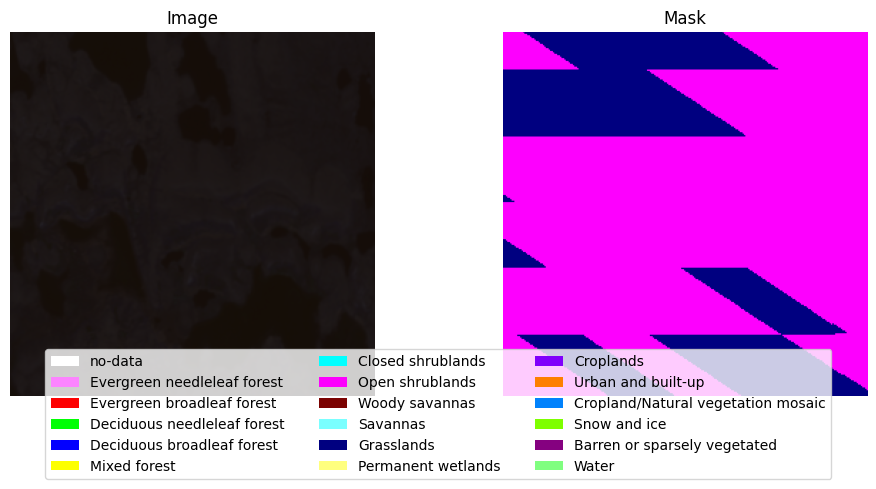

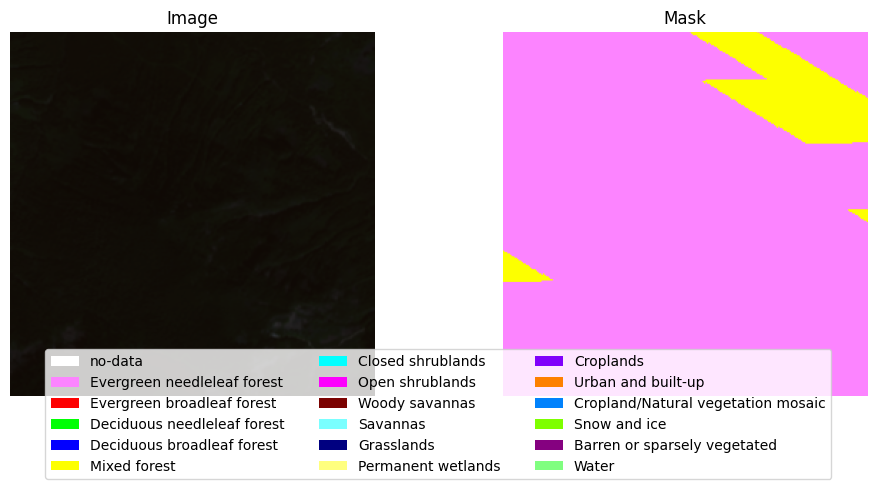

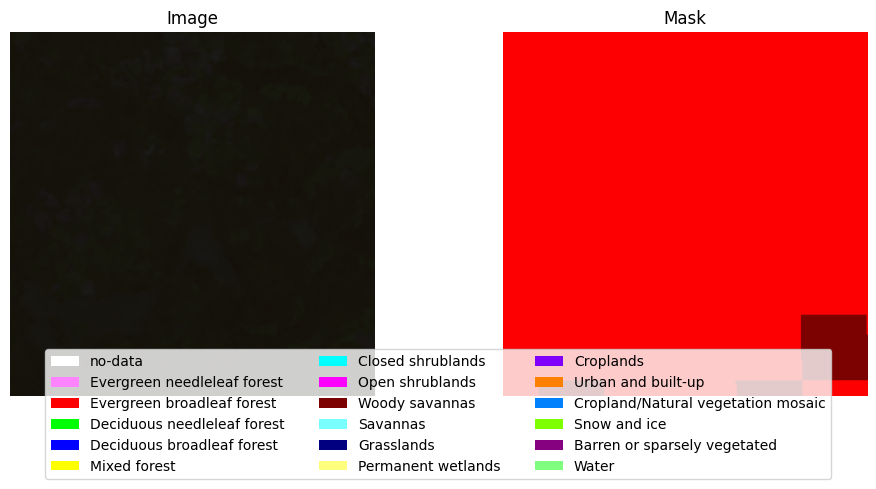

In [13]:
dataset_s2.show_image(1);
dataset_s2.show_image(50);
dataset_s2.show_image(999);

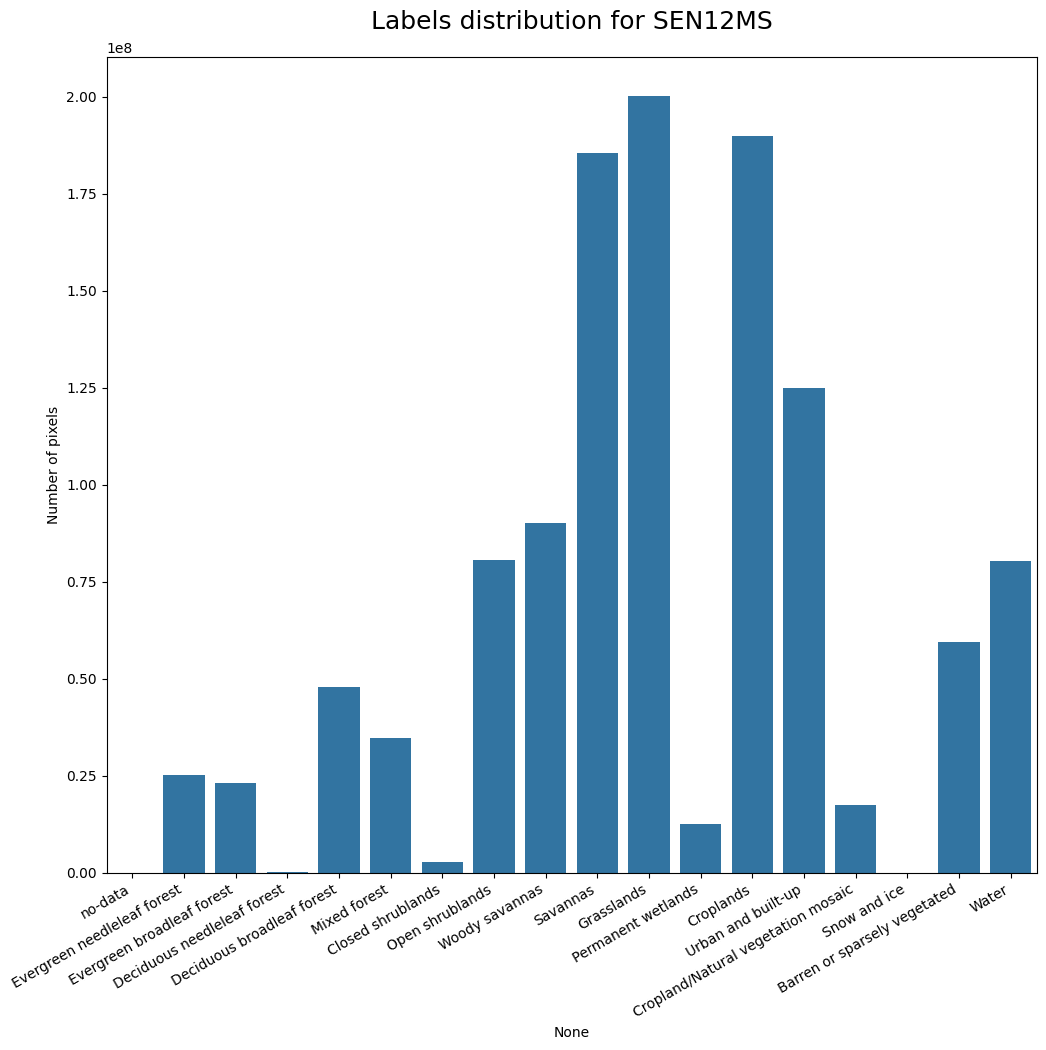

In [14]:
dataset_s2.data_distribution_barchart();

#### 2.1 Example: Get feature embeddings for Sentinel-2 images as input

In [ ]:
from aitlas.utils import image_loader
from aitlas.transforms import Transpose, ResizePerChannelToTensor
from torchvision.transforms import v2

# Define the number of images you want to load
N_batch = 4 

# Make sure we don't request more images than are in the dataset
if N_batch > len(dataset_s2):
    raise ValueError(f"Requested {N_batch} images, but dataset only has {len(dataset_s2)}.")

# Sentinel-2 bands wavelengths in micrometers
bands = {
    'B01': 0.443, 'B02': 0.490, 'B03': 0.560, 'B04': 0.665,
    'B05': 0.705, 'B06': 0.740, 'B07': 0.783, 'B08': 0.842,
    'B8A': 0.865, 'B09': 0.945, 'B10': 1.375, 'B11': 1.610,
    'B12': 2.190
}
s2_bands = ['B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12'] # Based on the AnySat documentation, these spectral bands are supported
all_s2_bands_list = list(bands.keys())
s2_band_indices = [all_s2_bands_list.index(b) for b in s2_bands]

# Normalization constants (AnySat requires all images to be normalized)
MEAN_S2 = torch.tensor([
        4304.32958984375,
        4159.2666015625,
        4057.776611328125,
        4328.951171875,
        4571.22119140625,
        4644.87109375,
        4837.2470703125,
        4700.2578125,
        2823.264404296875,
        2319.97021484375
    ]).float()
STD_S2 = torch.tensor([
        3537.99755859375,
        3324.23486328125,
        3270.070068359375,
        3250.530029296875,
        2897.391357421875,
        2754.4970703125,
        2821.521484375,
        2625.952392578125,
        1731.56298828125,
        1549.3028564453125
    ]).float()

# This list will hold each processed image tensor
image_tensors = []

# Load and process N_batch images
for i in range(N_batch):   
    # Load the image
    image = image_loader(dataset_s2.images[i])[:,:,s2_band_indices]
    # Transpose and transform the image
    transpose = Transpose()
    image = transpose(image) # Change from (H, W, C) to (C, H, W)
    image = (image - MEAN_S2[:, None, None]) / STD_S2[:, None, None] # Normalization (required by AnySat)
    transform = ResizePerChannelToTensor()
    image = transform(image)  # Do not add a batch dimension this time
    # Crop the image to 224x224 (center crop)
    image = v2.CenterCrop(224)(image)
    # Add the processed tensor to the list of image tensors
    image_tensors.append(image)

# Combine the list of tensors into a single batch tensor
image_batch = torch.stack(image_tensors, dim=0)
# Add a temporal dimension (only single timepoint in this example)
# The final shape will be (N_batch, T, C, H, W), as required for s2 (see https://github.com/gastruc/AnySat/blob/main/README.md)
s2 = image_batch.unsqueeze(1)

# Create dummy dates, as we do not have time series data (required)
dates_batch = torch.zeros(N_batch) # All zeros correspond to date 01/01 == 0; 31/12 = 364
s2_dates = dates_batch.unsqueeze(1) # The final shape must be (N_batch, T)

# Print the input data shapes
print(f"Input image shape: {image.shape}")
print(f"Input batch shape: {s2.shape}")
print(f"Input dates shape: {s2_dates.shape}")

Input image shape: torch.Size([10, 224, 224])
Input batch shape: torch.Size([4, 1, 10, 224, 224])
Input dates shape: torch.Size([4, 1])


Model inference (with 'tile' as output)

In [16]:
# Define the output parameters
patch_size = 160
output = 'tile'

if model_config["flash_attn"] == False: # Run on CPU without flash attention
    # Prepare the data dictionary
    data = {
        's2': s2, # BxTx10xHxW
        's2_dates': s2_dates, # BxT
    }   
    # Get the feature embeddings (one vector per tile)
    embeddings = model.forward_features(data, patch_size=patch_size, output=output) 
else: # Run on GPU with flash attention (must be installed beforehand)
    # Prepare the data dictionary
    gpu_id = 1
    data = {
        's2': s2.to(device=f'cuda:{gpu_id}', dtype=torch.float16), # BxTx10xHxW
        's2_dates': s2_dates.to(device=f'cuda:{gpu_id}', dtype=torch.int16) # BxT
    }
    # Move the model to GPU
    model = model.half().to(device=f'cuda:{gpu_id}')
    with torch.no_grad(), torch.autocast(device_type=f"cuda:{gpu_id}", dtype=torch.float16):
        # Get the feature embeddings (one vector per tile)
        embeddings = model.forward_features(data, patch_size=patch_size, output=output) 

# Print the embeddings shape
print(f"Embeddings shape: {embeddings.shape}")

torch.Size([4, 1, 10, 224, 224])
Embeddings shape: torch.Size([4, 768])


Model inference (with 'patch' as output)

In [17]:
# Define the output parameters
patch_size = 160
output = 'patch'

if model_config["flash_attn"] == False: # Run on CPU without flash attention
    # Prepare the data dictionary
    data = {
        's2': s2, # BxTx10xHxW
        's2_dates': s2_dates, # BxT
    }   
    # Get the feature embeddings (one vector per tile)
    embeddings = model.forward_features(data, patch_size=patch_size, output=output) 
else: # Run on GPU with flash attention (must be installed beforehand)
    # Prepare the data dictionary
    gpu_id = 1
    data = {
        's2': s2.to(device=f'cuda:{gpu_id}', dtype=torch.float16), # BxTx10xHxW
        's2_dates': s2_dates.to(device=f'cuda:{gpu_id}', dtype=torch.int16) # BxT
    }
    # Move the model to GPU
    model = model.half().to(device=f'cuda:{gpu_id}')
    with torch.no_grad(), torch.autocast(device_type=f"cuda:{gpu_id}", dtype=torch.float16):
        # Get the feature embeddings (one vector per tile)
        embeddings = model.forward_features(data, patch_size=patch_size, output=output) 

# Print the embeddings shape
print(f"Embeddings shape: {embeddings.shape}")

torch.Size([4, 1, 10, 224, 224])
Embeddings shape: torch.Size([4, 14, 14, 768])


Model inference (with 'all' as output)

In [18]:
# Define the output parameters
patch_size = 160
output = 'all'

if model_config["flash_attn"] == False: # Run on CPU without flash attention
    # Prepare the data dictionary
    data = {
        's2': s2, # BxTx10xHxW
        's2_dates': s2_dates, # BxT
    }   
    # Get the feature embeddings (one vector per tile)
    embeddings = model.forward_features(data, patch_size=patch_size, output=output) 
else: # Run on GPU with flash attention (must be installed beforehand)
    # Prepare the data dictionary
    gpu_id = 1
    data = {
        's2': s2.to(device=f'cuda:{gpu_id}', dtype=torch.float16), # BxTx10xHxW
        's2_dates': s2_dates.to(device=f'cuda:{gpu_id}', dtype=torch.int16) # BxT
    }
    # Move the model to GPU
    model = model.half().to(device=f'cuda:{gpu_id}')
    with torch.no_grad(), torch.autocast(device_type=f"cuda:{gpu_id}", dtype=torch.float16):
        # Get the feature embeddings (one vector per tile)
        embeddings = model.forward_features(data, patch_size=patch_size, output=output) 

# Print the embeddings shape
print(f"Embeddings shape: {embeddings.shape}")

torch.Size([4, 1, 10, 224, 224])
Embeddings shape: torch.Size([4, 197, 768])


Model inference (with 'dense' as output)

In [19]:
# Define the output parameters
patch_size = 160
output = 'dense'
output_modality = 's2'

if model_config["flash_attn"] == False: # Run on CPU without flash attention
    # Prepare the data dictionary
    data = {
        's2': s2, # BxTx10xHxW
        's2_dates': s2_dates, # BxT
    }   
    # Get the feature embeddings (one vector per tile)
    embeddings = model.forward_features(data, patch_size=patch_size, output=output, output_modality=output_modality) 
else: # Run on GPU with flash attention (must be installed beforehand)
    # Prepare the data dictionary
    gpu_id = 1
    data = {
        's2': s2.to(device=f'cuda:{gpu_id}', dtype=torch.float16), # BxTx10xHxW
        's2_dates': s2_dates.to(device=f'cuda:{gpu_id}', dtype=torch.int16) # BxT
    }
    # Move the model to GPU
    model = model.half().to(device=f'cuda:{gpu_id}')
    with torch.no_grad(), torch.autocast(device_type=f"cuda:{gpu_id}", dtype=torch.float16):
        # Get the feature embeddings (one vector per tile)
        embeddings = model.forward_features(data, patch_size=patch_size, output=output, output_modality=output_modality) 

# Print the embeddings shape
print(f"Embeddings shape: {embeddings.shape}")

torch.Size([4, 1, 10, 224, 224])
Embeddings shape: torch.Size([4, 224, 224, 1536])
